# Calculate the metrics from the csv

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from evaluation_utils import bootstrap_from_csv
import pickle
from pathlib import Path

In [2]:


# --- CALCULATION ---
models_to_test = {
    "DINOv2 (Video)": "csvs/dinov2_open/open_dist_matrix.csv",
    "DINOv2 (Image)": "csvs/dinov2_open_image/open_dist_matrix.csv",
    "SwinV2 (Video)": "csvs/swin_open/open_dist_matrix.csv",
    "SwinV2 (Image)": "csvs/swin_open_image/open_dist_matrix.csv",
    "ViT (Video)":    "csvs/vit_open/open_dist_matrix.csv",
    "ViT (Image)":    "csvs/vit_open_image/open_dist_matrix.csv"
}

# Dictionary to store all computed metrics
all_open_results = {}

for name, path in models_to_test.items():
    print(f"\n{'='*30}\nProcessing {name}\n{'='*30}")
    all_open_results[name] = bootstrap_from_csv(path, m=100, mode="open")


# --- Save Configuration ---
SAVE_DIR = Path("results_data")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# Define a filename for saving results
FILENAME = f"open_world_benchmarks.pkl"
SAVE_PATH = SAVE_DIR / FILENAME

print(f"\n-> Saving all results to {SAVE_PATH}...")

with open(SAVE_PATH, 'wb') as f:
    pickle.dump(all_open_results, f)

print("✅ Results saved successfully.")


Processing DINOv2 (Video)
-> Bootstrapping 'open' metrics from CSV (100 iterations)...


100%|██████████| 100/100 [00:07<00:00, 13.67it/s]



Processing DINOv2 (Image)
-> Bootstrapping 'open' metrics from CSV (100 iterations)...


100%|██████████| 100/100 [00:06<00:00, 14.52it/s]



Processing SwinV2 (Video)
-> Bootstrapping 'open' metrics from CSV (100 iterations)...


...


Processing ViT (Video)
-> Bootstrapping 'open' metrics from CSV (100 iterations)...


100%|██████████| 100/100 [00:06<00:00, 15.74it/s]



Processing ViT (Image)
-> Bootstrapping 'open' metrics from CSV (100 iterations)...


100%|██████████| 100/100 [00:06<00:00, 15.57it/s]


-> Saving all results to results_data\open_world_benchmarks.pkl...
✅ Results saved successfully.


In [3]:
# Load the saved data
LOAD_PATH = "results_data/open_world_benchmarks.pkl"

with open(LOAD_PATH, 'rb') as f:
    all_results = pickle.load(f)

print(f"Loaded results for: {list(all_results.keys())}")

Loaded results for: ['DINOv2 (Video)', 'DINOv2 (Image)', 'SwinV2 (Video)', 'SwinV2 (Image)', 'ViT (Video)', 'ViT (Image)']


In [4]:
print("\n" + "="*110)
print(f"{'Model (Rank)':<25} | {'FAR=1% [95% CI]':<25} | {'FAR=5% [95% CI]':<25} | {'FAR=10% [95% CI]':<25}")
print("="*110)

for name, res in all_results.items():
    fars = res["mean_fars"]
    
    row_vals_r1 = []
    row_vals_r5 = []
    
    for target in [0.01, 0.05, 0.10]:
        idx = np.argmin(np.abs(fars - target))
        
        # --- Rank-1 Extractions ---
        r1_mean = res["mean_dirs_r1"][idx]
        r1_low  = res["lower_dirs_r1"][idx]
        r1_high = res["upper_dirs_r1"][idx]
        r1_str  = f"{r1_mean:.3f} [{r1_low:.3f}, {r1_high:.3f}]"
        row_vals_r1.append(r1_str)
        
        # --- Rank-5 Extractions ---
        r5_mean = res["mean_dirs_r5"][idx]
        r5_low  = res["lower_dirs_r5"][idx]
        r5_high = res["upper_dirs_r5"][idx]
        r5_str  = f"{r5_mean:.3f} [{r5_low:.3f}, {r5_high:.3f}]"
        row_vals_r5.append(r5_str)
    
    # Print Rank 1 row
    print(f"{name + ' (R1)':<25} | {row_vals_r1[0]:<25} | {row_vals_r1[1]:<25} | {row_vals_r1[2]:<25}")
    
    # Print Rank 5 row
    print(f"{name + ' (R5)':<25} | {row_vals_r5[0]:<25} | {row_vals_r5[1]:<25} | {row_vals_r5[2]:<25}")
    
    print("-" * 110)


Model (Rank)              | FAR=1% [95% CI]           | FAR=5% [95% CI]           | FAR=10% [95% CI]         
DINOv2 (Video) (R1)       | 0.062 [0.048, 0.084]      | 0.130 [0.107, 0.156]      | 0.229 [0.201, 0.255]     
DINOv2 (Video) (R5)       | 0.066 [0.052, 0.088]      | 0.147 [0.122, 0.170]      | 0.263 [0.234, 0.287]     
--------------------------------------------------------------------------------------------------------------
DINOv2 (Image) (R1)       | 0.038 [0.027, 0.053]      | 0.108 [0.090, 0.128]      | 0.182 [0.157, 0.206]     
DINOv2 (Image) (R5)       | 0.041 [0.030, 0.056]      | 0.125 [0.108, 0.148]      | 0.218 [0.191, 0.245]     
--------------------------------------------------------------------------------------------------------------
SwinV2 (Video) (R1)       | 0.023 [0.014, 0.035]      | 0.049 [0.037, 0.066]      | 0.082 [0.064, 0.099]     
SwinV2 (Video) (R5)       | 0.031 [0.021, 0.042]      | 0.079 [0.065, 0.098]      | 0.134 [0.107, 0.159]     
-------

C:\Users\marko\AppData\Local\Temp\ipykernel_23032\3948419525.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(all_results))


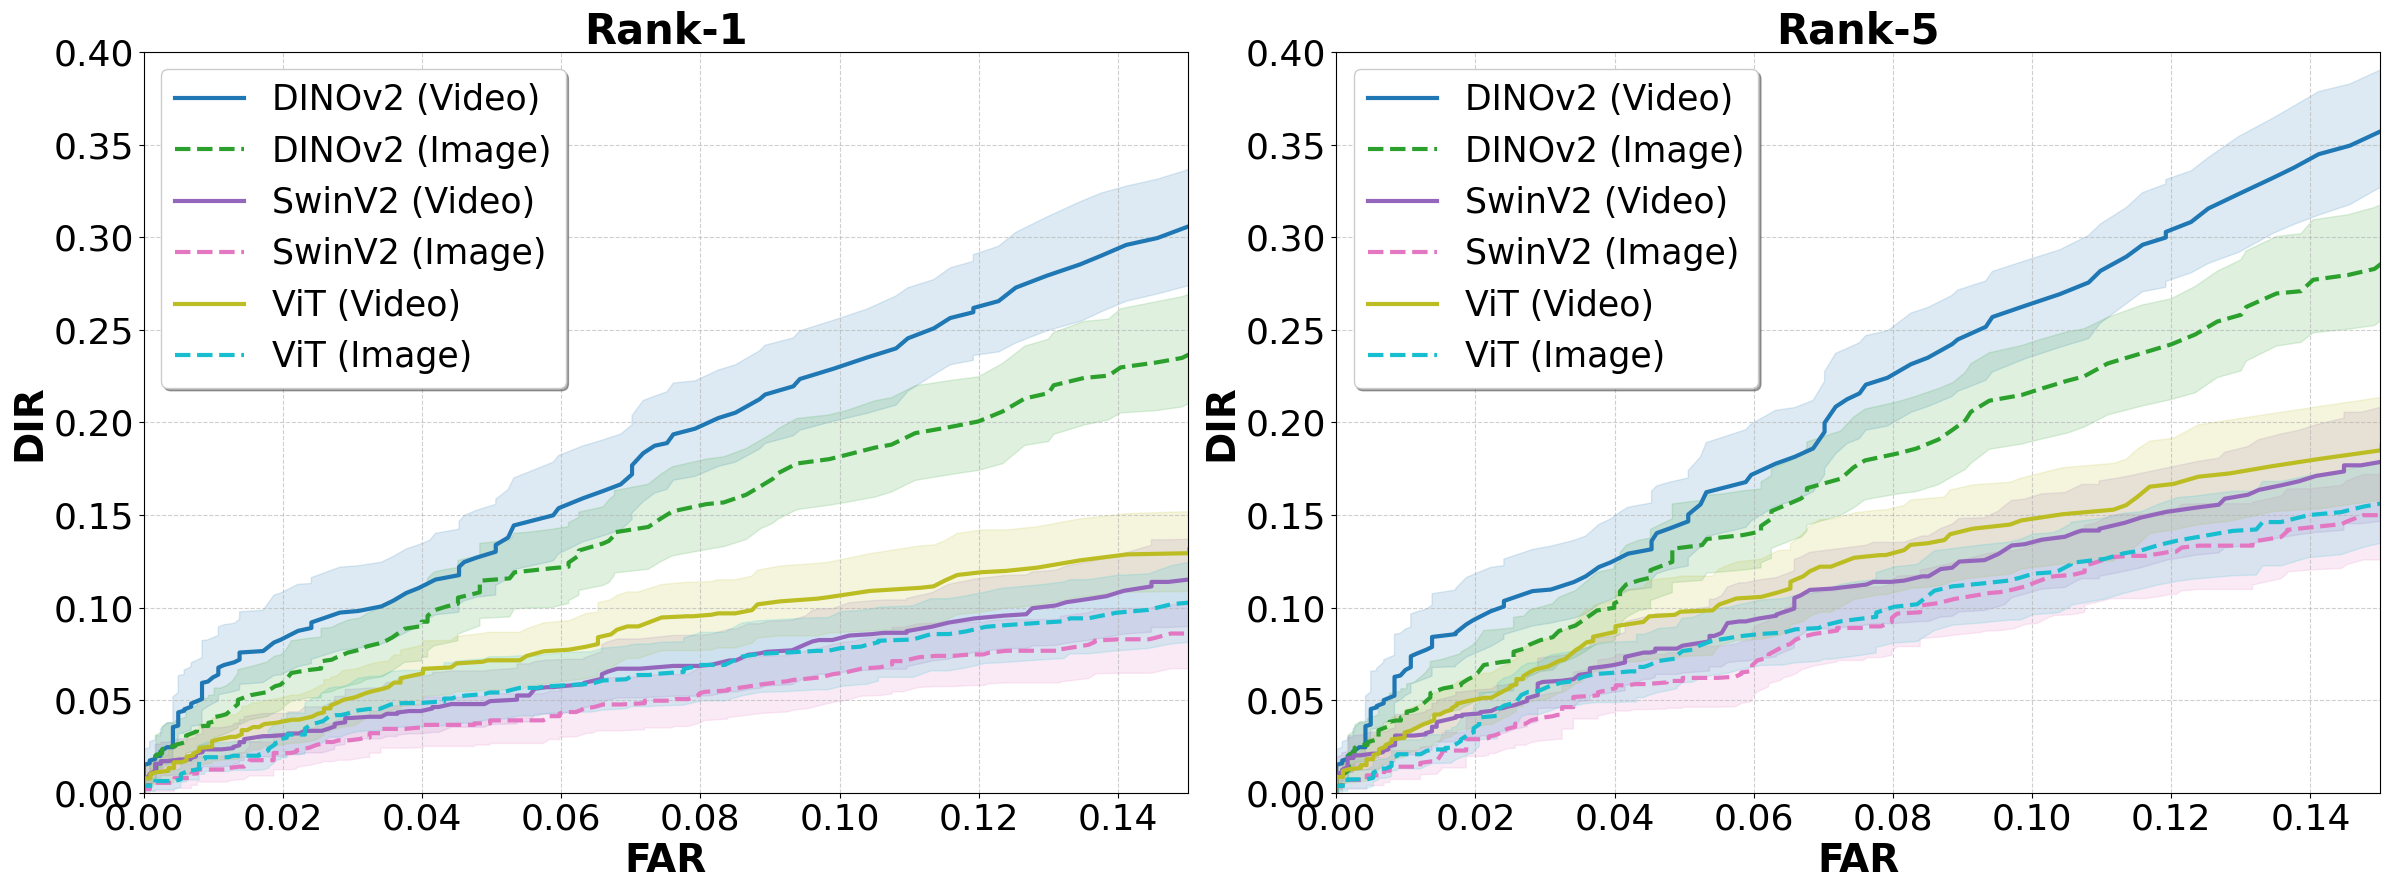

In [18]:
# -------------------------------------------------------------
# --- Plotting Configuration ---
# -------------------------------------------------------------
MAX_FAR = 0.15 
FAR_TICK_STEP = 0.02
FONT_SIZE = 26 

# Separate MAX_DIR limits because Rank-5 values will be much higher than Rank-1
MAX_DIR_R1 = 0.4
MAX_DIR_R5 = 0.4  # <-- Adjust this depending on your results

# -------------------------------------------------------------
# --- Plotting Open-World Curves (Side-by-Side Subplots) ---
# -------------------------------------------------------------

# Create a figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(24, 9)) 

plot_configs = [
    {"suffix": "r1", "title": "Rank-1", "max_dir": MAX_DIR_R1, "ax": axes[0]},
    {"suffix": "r5", "title": "Rank-5", "max_dir": MAX_DIR_R5, "ax": axes[1]}
]

for config in plot_configs:
    ax = config["ax"]
    colors = plt.cm.get_cmap('tab10', len(all_results))
    
    for i, (name, res) in enumerate(all_results.items()):
        fars       = res["mean_fars"]
        
        dirs       = res[f"mean_dirs_{config['suffix']}"]
        dirs_lower = res[f"lower_dirs_{config['suffix']}"]
        dirs_upper = res[f"upper_dirs_{config['suffix']}"]
        
        color = colors(i)
        
        ax.fill_between(fars, dirs_lower, dirs_upper, color=color, alpha=0.15)
        
        line_style = '-' if "(Video)" in name or "(Image)" not in name else '--'
        ax.plot(fars, dirs, color=color, linestyle=line_style, linewidth=3, label=name)

    # --- Format the Subplot with Larger Fonts ---
    ax.set_title(config["title"], fontsize=FONT_SIZE + 4, fontweight='bold')
    ax.set_xlabel("FAR", fontsize=FONT_SIZE + 2, fontweight='bold')
    ax.set_ylabel("DIR", fontsize=FONT_SIZE + 2, fontweight='bold')

    # --- Axis Tick Labels ---
    ax.set_xticks(np.arange(0, MAX_FAR + 0.01, step=FAR_TICK_STEP))
    ax.tick_params(axis='both', which='major', labelsize=FONT_SIZE)

    # --- Dynamic Axis Control ---
    ax.set_xlim(0, MAX_FAR) 
    ax.set_ylim(0, config["max_dir"]) 

    ax.grid(True, linestyle='--', alpha=0.6)

    # --- Legend Configuration ---
    ax.legend(fontsize=FONT_SIZE - 1, loc='upper left', frameon=True, shadow=True, facecolor='white')

plt.tight_layout()
plt.savefig("figs/open_world.png")
plt.show()